## Penguins

<img src= https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguin.png width=600 >


#### Columns in the dataset
- species: penguin species (Chinstrap, Adélie, or Gentoo)
- island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
- bill_length_mm: bill length (mm)
- bill_length_mm: bill depth (mm)
- flipper_length_mm: flipper length (mm)
- body_mass_g: body mass (g)
- Sex: penguin sex

<img src= https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguin2.png width=600 >


In [47]:
!wget https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv

--2024-11-18 10:21:14--  https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv
Resolving frenzy86.s3.eu-west-2.amazonaws.com (frenzy86.s3.eu-west-2.amazonaws.com)... 3.5.245.234, 52.95.150.182, 52.95.150.134, ...
Connecting to frenzy86.s3.eu-west-2.amazonaws.com (frenzy86.s3.eu-west-2.amazonaws.com)|3.5.245.234|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15134 (15K) [text/csv]
Saving to: ‘penguins.csv’

penguins.csv        100%[===================>]  14,78K  --.-KB/s    in 0s      

2024-11-18 10:21:14 (191 MB/s) - ‘penguins.csv’ saved [15134/15134]



In [48]:
path = "https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv"

In [49]:
import pandas as pd

df=pd.read_csv(path)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male
1,Adelie,Torgersen,39.5,17.4,186,3800,female
2,Adelie,Torgersen,40.3,18.0,195,3250,female
3,Adelie,Torgersen,36.7,19.3,193,3450,female
4,Adelie,Torgersen,39.3,20.6,190,3650,male
...,...,...,...,...,...,...,...
328,Chinstrap,Dream,55.8,19.8,207,4000,male
329,Chinstrap,Dream,43.5,18.1,202,3400,female
330,Chinstrap,Dream,49.6,18.2,193,3775,male
331,Chinstrap,Dream,50.8,19.0,210,4100,male


In [50]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [51]:
df['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [52]:
df['island'].value_counts()

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

In [53]:
island={'Biscoe':0,'Dream':1,'Torgensen':2}
sex={'male':0,'female':1}
df['island']=df['island'].map(island)
df['sex']=df['sex'].map(sex)

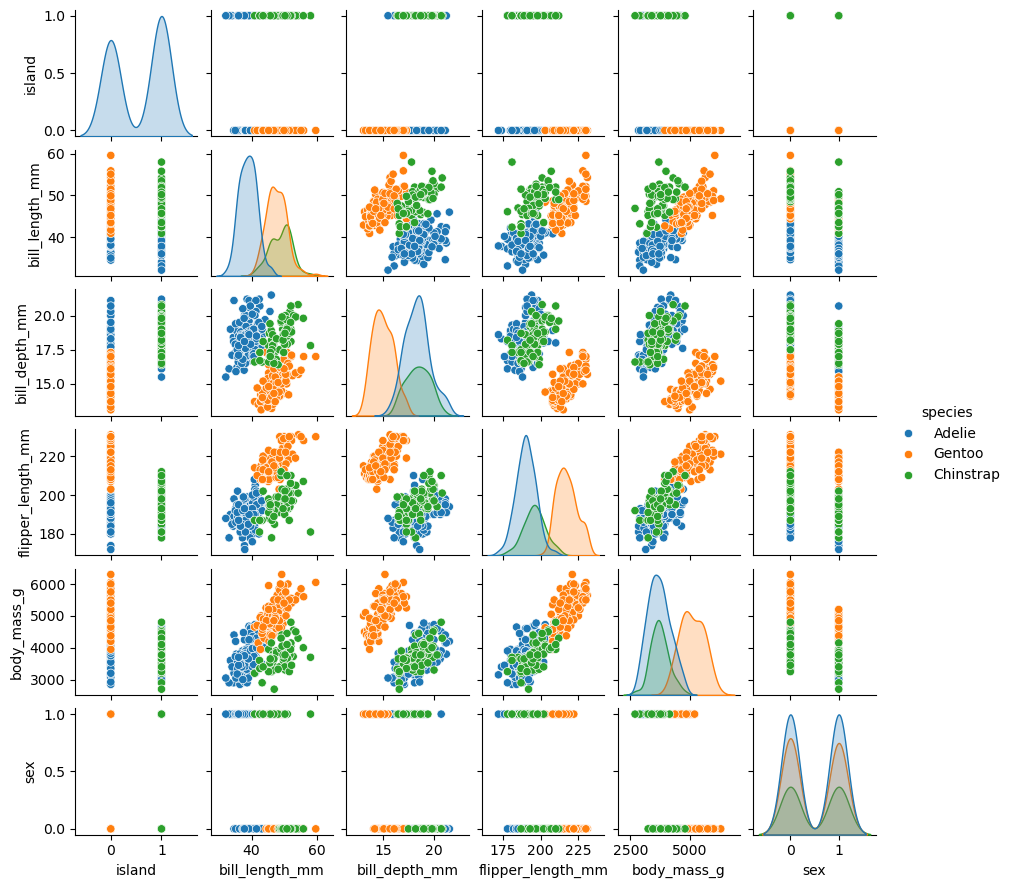

In [54]:
import seaborn as sns
sns.pairplot(df, hue='species',height=1.5)

In [55]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()

In [56]:
df_agg=df[['species','island']]

In [57]:
import numpy as np
agg=df_agg.groupby(['island','species'])
agg.aggregate(np.sum)

/tmp/ipykernel_10526/82212390.py:3: FutureWarning: The provided callable <function sum at 0x7b6c8291a8e0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  agg.aggregate(np.sum)


Empty DataFrame
Columns: []
Index: [(0.0, Adelie), (0.0, Gentoo), (1.0, Adelie), (1.0, Chinstrap)]

In [58]:
from sklearn.model_selection import train_test_split
X=df[['island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g']]
y=df[['species']]

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,train_size=0.75,random_state=69)

In [59]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [60]:
model.score(X_test,y_test)

1.0

In [62]:
from sklearn.model_selection import cross_val_score

cross_val_score(model,X,y,cv=5)

/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(esti

array([1.        , 0.98507463, 0.98507463, 1.        , 0.98484848])